In [1]:
import datetime
print(f"Notebook last run{datetime.datetime.now()}")

Notebook last run2026-04-22 12:27:37.665905


In [2]:
import zipfile

#download
# !wget https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip 

# #unzip
# zip_ref = zipfile.ZipFile("pizza_steak.zip", "r")
# zip_ref.extractall()
# zip_ref.close()

In [3]:
import os

for dirpath, dirnames, filenames in os.walk("pizza_steak"):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in {dirpath}")



There are 2 directories and 0 images in pizza_steak
There are 2 directories and 0 images in pizza_steak/test
There are 0 directories and 250 images in pizza_steak/test/steak
There are 0 directories and 250 images in pizza_steak/test/pizza
There are 2 directories and 0 images in pizza_steak/train
There are 0 directories and 750 images in pizza_steak/train/steak
There are 0 directories and 750 images in pizza_steak/train/pizza


In [4]:
import pathlib
import numpy as np
data_dir = pathlib.Path("pizza_steak/train/")
class_names = np.array(sorted([item.name for item in data_dir.glob('*')]))
print(class_names)

['pizza' 'steak']


In [5]:
# View an image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

def view_random_image(target_dir, target_class):
  # Setup target directory (we'll view images from here)
  target_folder = target_dir+target_class

  # Get a random image path
  random_image = random.sample(os.listdir(target_folder), 1)

  # Read in the image and plot it using matplotlib
  img = mpimg.imread(target_folder + "/" + random_image[0])
  plt.imshow(img)
  plt.title(target_class)
  plt.axis("off");

  print(f"Image shape: {img.shape}") # show the shape of the image

  return img

Image shape: (512, 512, 3)


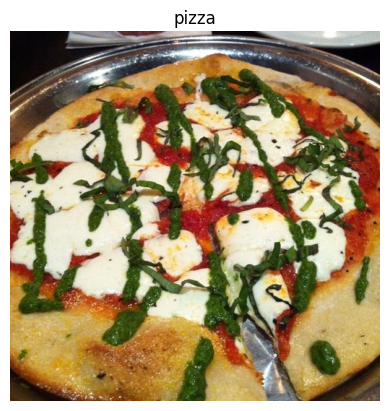

In [6]:
# View a random image from the training dataset
img = view_random_image(target_dir="pizza_steak/train/",
                        target_class="pizza")

In [7]:
img

array([[[  8,   6,  11],
        [  9,   7,  12],
        [ 10,   8,  13],
        ...,
        [178, 188, 177],
        [181, 191, 180],
        [182, 192, 181]],

       [[ 10,   8,  13],
        [  9,   7,  12],
        [  9,   7,  12],
        ...,
        [181, 191, 180],
        [182, 192, 183],
        [182, 192, 181]],

       [[ 11,   9,  14],
        [ 10,   8,  13],
        [  8,   6,  11],
        ...,
        [184, 194, 185],
        [183, 193, 185],
        [182, 192, 183]],

       ...,

       [[ 68,  38,  27],
        [ 63,  34,  20],
        [ 59,  30,  16],
        ...,
        [ 90,  74,  59],
        [ 93,  77,  64],
        [ 91,  75,  62]],

       [[ 79,  49,  39],
        [ 70,  40,  29],
        [ 62,  33,  19],
        ...,
        [ 84,  68,  55],
        [ 94,  77,  67],
        [ 97,  80,  70]],

       [[ 99,  69,  59],
        [ 87,  57,  46],
        [ 74,  44,  33],
        ...,
        [ 89,  73,  60],
        [100,  83,  73],
        [106,  89,  79]]

In [8]:
img.shape

(512, 512, 3)

In [9]:
import numpy as np

print(img.shape)        # (384, 512, 3)
vmin = img.min()        # or np.min(img)
vmax = img.max()        # or np.max(img)

print(vmin, vmax)

(512, 512, 3)
0 255


In [10]:
img/255.

array([[[0.03137255, 0.02352941, 0.04313725],
        [0.03529412, 0.02745098, 0.04705882],
        [0.03921569, 0.03137255, 0.05098039],
        ...,
        [0.69803922, 0.7372549 , 0.69411765],
        [0.70980392, 0.74901961, 0.70588235],
        [0.71372549, 0.75294118, 0.70980392]],

       [[0.03921569, 0.03137255, 0.05098039],
        [0.03529412, 0.02745098, 0.04705882],
        [0.03529412, 0.02745098, 0.04705882],
        ...,
        [0.70980392, 0.74901961, 0.70588235],
        [0.71372549, 0.75294118, 0.71764706],
        [0.71372549, 0.75294118, 0.70980392]],

       [[0.04313725, 0.03529412, 0.05490196],
        [0.03921569, 0.03137255, 0.05098039],
        [0.03137255, 0.02352941, 0.04313725],
        ...,
        [0.72156863, 0.76078431, 0.7254902 ],
        [0.71764706, 0.75686275, 0.7254902 ],
        [0.71372549, 0.75294118, 0.71764706]],

       ...,

       [[0.26666667, 0.14901961, 0.10588235],
        [0.24705882, 0.13333333, 0.07843137],
        [0.23137255, 0

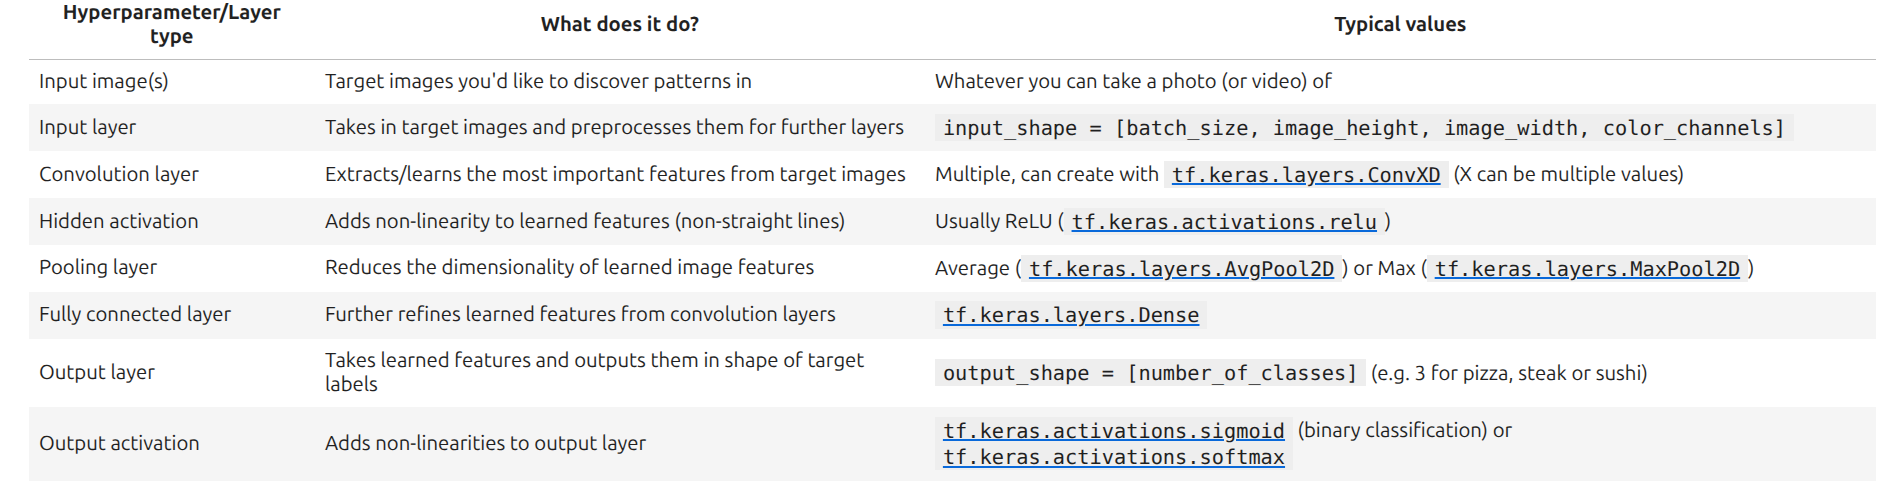

# Binary classification

## 1-  CNN model

In [11]:
#new style: implemented in model_5
# train_ds = tf.keras.utils.image_dataset_from_directory(
#     "data/train",
#     image_size=(224, 224),
#     batch_size=32,
#     label_mode="categorical",
# )

# data_augmentation = tf.keras.Sequential(
#     [
#         tf.keras.layers.RandomFlip("horizontal"),
#         tf.keras.layers.RandomRotation(0.1),
#         tf.keras.layers.RandomZoom(0.1),
#     ]
# )

# model = tf.keras.Sequential(
#     [
#         tf.keras.layers.Input(shape=(224, 224, 3)),
#         tf.keras.layers.Rescaling(1./255),
#         data_augmentation,
#         # ... rest of your model
#     ]
# )

# model.fit(train_ds, epochs=10)

In [12]:
#replicating a downscale of TinyVGG
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#set the seed
tf.random.set_seed(42)

#preprocess data(normalization)
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

#setup the train and test directories
train_dir = "pizza_steak/train"
test_dir = "pizza_steak/test"

# import data from dir and turn into batches
train_data = train_datagen.flow_from_directory(train_dir,
                                               batch_size = 32,
                                               target_size = (224,224),
                                               class_mode="binary",
                                               seed=42)
valid_data = valid_datagen.flow_from_directory(test_dir,
                                               batch_size = 32,
                                               target_size = (224,224),
                                               class_mode="binary",
                                               seed=42)

#create a CNN model(same as TinyVGG)
model_1 = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(filters=10, kernel_size=(3,3), activation="relu", input_shape=(224,224,3)),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=(2,2), padding="valid"),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# Compile the model
model_1.compile(loss="binary_crossentropy",
                optimizer="adam",
                metrics=["accuracy"])

#Fit the model
history_1 = model_1.fit(train_data,
                        epochs=5,
                        validation_data=valid_data,
                        validation_steps=len(valid_data))

I0000 00:00:1776853658.404330 1030479 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776853658.433620 1030479 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776853659.081896 1030479 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.
Epoch 1/5


/home/paminidigehsara/Desktop/controlEx_prep/.venv_ce/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
W0000 00:00:1776853659.759070 1030479 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
I0000 00:00:1776853659.880432 1030479 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - accuracy: 0.6527 - loss: 0.6336 - val_accuracy: 0.7460 - val_loss: 0.5307
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - accuracy: 0.7680 - loss: 0.5007 - val_accuracy: 0.8240 - val_loss: 0.4235
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - accuracy: 0.7953 - loss: 0.4436 - val_accuracy: 0.8560 - val_loss: 0.3722
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.8433 - loss: 0.3812 - val_accuracy: 0.8660 - val_loss: 0.3256
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - accuracy: 0.8507 - loss: 0.3478 - val_accuracy: 0.8820 - val_loss: 0.2943


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        28,091 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,305 (364.48 KB)

 Trainable params: 31,101 (121.49 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,204 (242.99 KB)

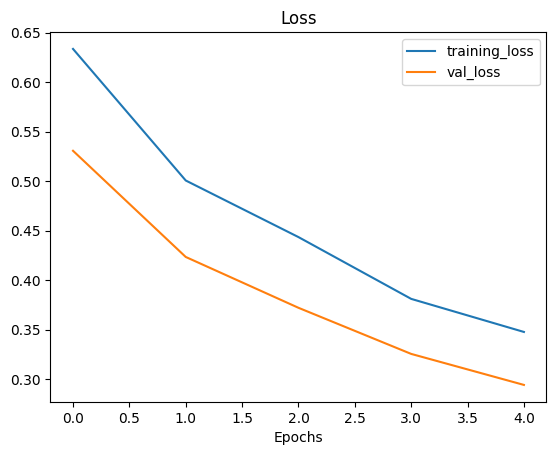

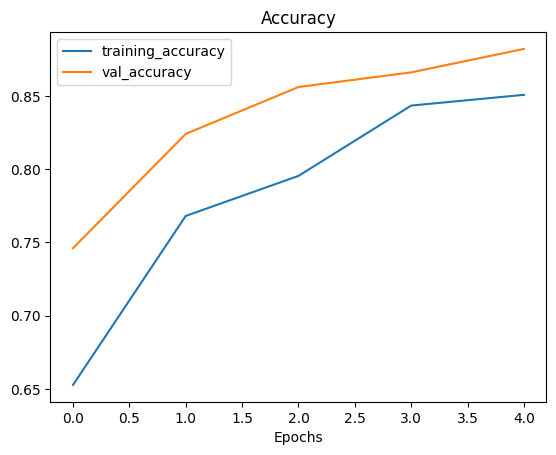

In [13]:
from utils import plot_training_history
model_1.summary()
plot_training_history(history=history_1)

## 2-  MLP model (naive)

In [14]:
# Set random seed
tf.random.set_seed(42)

# Create a model to replicate the TensorFlow Playground model
model_2 = tf.keras.Sequential([
  tf.keras.layers.Flatten(input_shape=(224, 224, 3)), # dense layers expect a 1-dimensional vector as input
  tf.keras.layers.Dense(4, activation='relu'),
  tf.keras.layers.Dense(4, activation='relu'),
  tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile the model
model_2.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

# Fit the model
history_2 = model_2.fit(train_data, # use same training data created above
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=valid_data, # use same validation data created above
                        validation_steps=len(valid_data))

Epoch 1/5


/home/paminidigehsara/Desktop/controlEx_prep/.venv_ce/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.4960 - loss: 0.6930 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.5000 - loss: 0.6927 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.4927 - loss: 0.6949 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.4773 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.4880 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │       602,116 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,806,425 (6.89 MB)

 Trainable params: 602,141 (2.30 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,204,284 (4.59 MB)

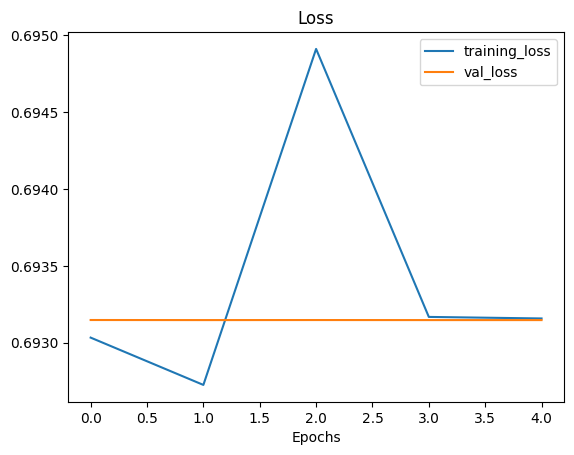

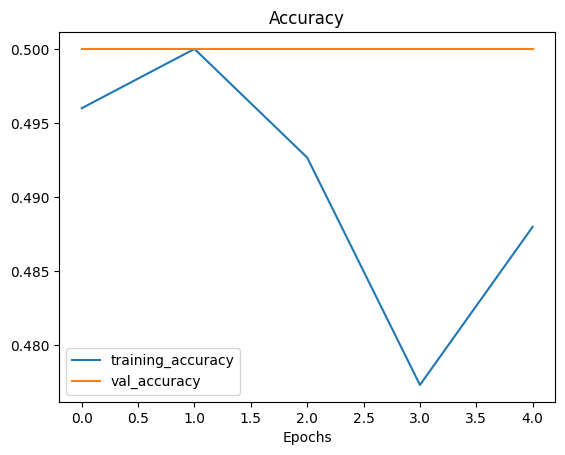

In [15]:
from utils import plot_training_history
model_2.summary()
plot_training_history(history=history_2)

## 3-  MLP model (more complex)

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - accuracy: 0.6087 - loss: 2.6091 - val_accuracy: 0.6040 - val_loss: 1.5990
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - accuracy: 0.6733 - loss: 0.8346 - val_accuracy: 0.7360 - val_loss: 0.5865
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.7360 - loss: 0.5598 - val_accuracy: 0.7320 - val_loss: 0.5573
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.7660 - loss: 0.5256 - val_accuracy: 0.7800 - val_loss: 0.4666
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.7540 - loss: 0.5345 - val_accuracy: 0.7820 - val_loss: 0.4547


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │    15,052,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,219,605 (172.50 MB)

 Trainable params: 15,073,201 (57.50 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 30,146,404 (115.00 MB)

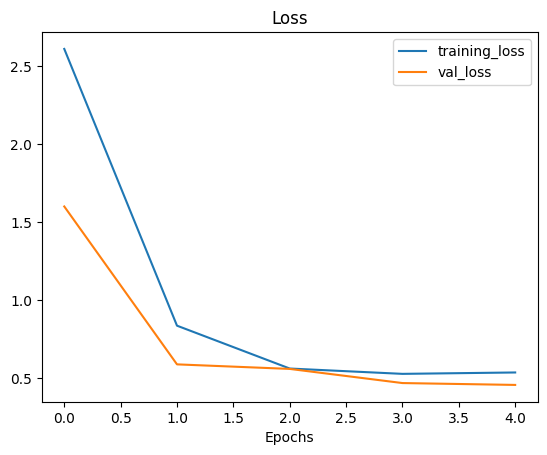

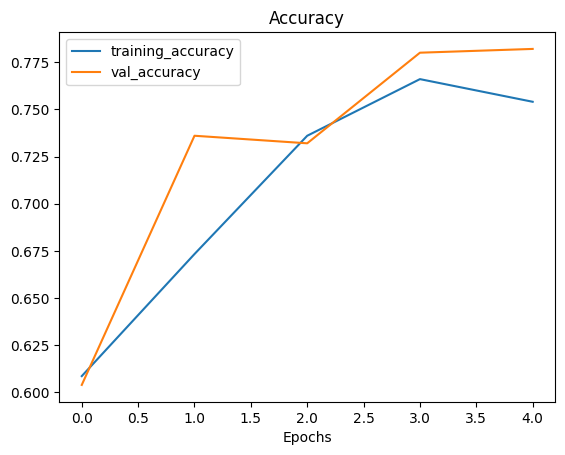

In [16]:
# Set random seed
tf.random.set_seed(42)

# Create a model similar to model_1 but add an extra layer and increase the number of hidden units in each layer
model_3 = tf.keras.Sequential([
  tf.keras.layers.Flatten(input_shape=(224, 224, 3)), # dense layers expect a 1-dimensional vector as input
  tf.keras.layers.Dense(100, activation='relu'), # increase number of neurons from 4 to 100 (for each layer)
  tf.keras.layers.Dense(100, activation='relu'),
  tf.keras.layers.Dense(100, activation='relu'), # add an extra layer
  tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile the model
model_3.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

# Fit the model
history_3 = model_3.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=valid_data,
                        validation_steps=len(valid_data))
from utils import plot_training_history
model_3.summary()
plot_training_history(history=history_3)

## We just went through a whirlwind of steps:  

1- Become one with the data (visualize, visualize, visualize...)  
2- Preprocess the data (prepare it for a model)  
3- Create a model (start with a baseline)  
4- Fit the model  
5- Evaluate the model  
6- Adjust different parameters and improve model (try to beat your baseline)  
7- Repeat until satisfied  

## 4-  CNN with simple structure(see overfitting)

In [17]:
# Make the creating of our model a little easier
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D, Activation
from tensorflow.keras import Sequential

# Create the model (this can be our baseline, a 3 layer Convolutional Neural Network)
model_4 = Sequential([
  Conv2D(filters=10, 
         kernel_size=3, 
         strides=1,
         padding='valid',
         activation='relu', 
         input_shape=(224, 224, 3)), # input layer (specify input shape)
  Conv2D(10, 3, activation='relu'),
  Conv2D(10, 3, activation='relu'),
  Flatten(),
  Dense(1, activation='sigmoid') # output layer (specify output shape)
])

# Compile the model
model_4.compile(loss='binary_crossentropy',
                optimizer=Adam(),
                metrics=['accuracy'])
# Fit the model
history_4 = model_4.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=valid_data,
                        validation_steps=len(valid_data))

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - accuracy: 0.6927 - loss: 1.2758 - val_accuracy: 0.8000 - val_loss: 0.4336
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - accuracy: 0.7987 - loss: 0.4480 - val_accuracy: 0.8380 - val_loss: 0.3806
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - accuracy: 0.8447 - loss: 0.3683 - val_accuracy: 0.8260 - val_loss: 0.3761
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - accuracy: 0.9320 - loss: 0.2168 - val_accuracy: 0.8100 - val_loss: 0.3876
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - accuracy: 0.9747 - loss: 0.0926 - val_accuracy: 0.7620 - val_loss: 0.5670


In [18]:
# Check lengths of training and test data generators
len(train_data), len(valid_data)

(47, 16)

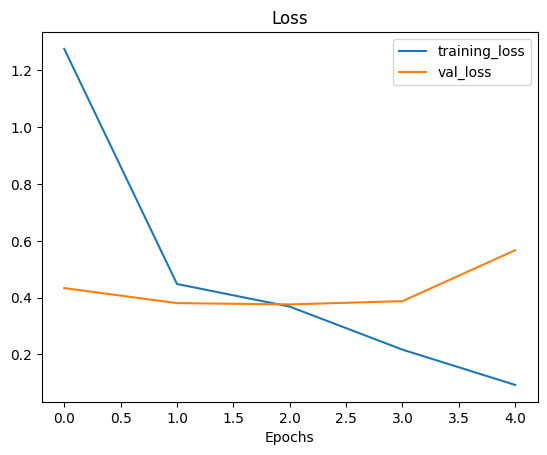

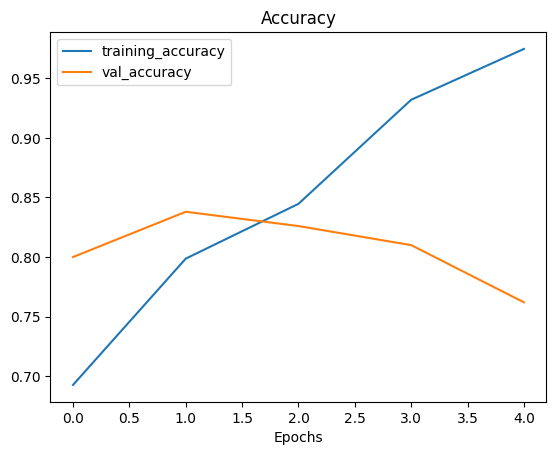

In [19]:
# Check out the loss curves of model_4
plot_training_history(history_4)

In [20]:
# Check out our model's architecture
model_4.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 218, 218, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 475240)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │       475,241 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,432,025 (5.46 MB)

 Trainable params: 477,341 (1.82 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 954,684 (3.64 MB)

## 5-  CNN model (more complex by adding more layers) Try to beat the overfitting


In [21]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "pizza_steak//train",
    image_size=(224, 224),
    batch_size=32,
    label_mode="binary",
)
valid_ds = tf.keras.utils.image_dataset_from_directory(
    "pizza_steak//test",
    image_size=(224, 224),
    batch_size=32,
    label_mode="binary",
)
## NOT NOW
# data_augmentation = tf.keras.Sequential(
#     [
#         tf.keras.layers.RandomFlip("horizontal"),
#         tf.keras.layers.RandomRotation(0.1),
#         tf.keras.layers.RandomZoom(0.1),
#     ]
# )
model_5 = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(224, 224, 3)),
        tf.keras.layers.Rescaling(1./255),
        tf.keras.layers.Conv2D(10,3,activation="relu"),
        tf.keras.layers.MaxPool2D(pool_size=2),
        tf.keras.layers.Conv2D(10,3,activation="relu"),
        tf.keras.layers.MaxPool2D(),
        tf.keras.layers.Conv2D(10,3,activation="relu"),
        tf.keras.layers.MaxPool2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(1, activation="sigmoid")
        ])

model_5.compile(loss="binary_crossentropy",
                optimizer="adam",
                metrics=["accuracy"])

history_5 = model_5.fit(train_ds,
                        epochs=5,
                        steps_per_epoch=len(train_ds),
                        validation_data=valid_ds,
                        validation_steps=len(valid_ds))

Found 1500 files belonging to 2 classes.
Found 500 files belonging to 2 classes.
Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.6800 - loss: 0.6130 - val_accuracy: 0.7200 - val_loss: 0.5580
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.7620 - loss: 0.4983 - val_accuracy: 0.8200 - val_loss: 0.3952
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.8073 - loss: 0.4345 - val_accuracy: 0.8340 - val_loss: 0.3787
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.8167 - loss: 0.4155 - val_accuracy: 0.8060 - val_loss: 0.4190
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.8267 - loss: 0.3992 - val_accuracy: 0.8460 - val_loss: 0.3373


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 109, 109, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 52, 52, 10)     │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 26, 26, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 6760)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │         6,761 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,585 (103.85 KB)

 Trainable params: 8,861 (34.61 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 17,724 (69.24 KB)

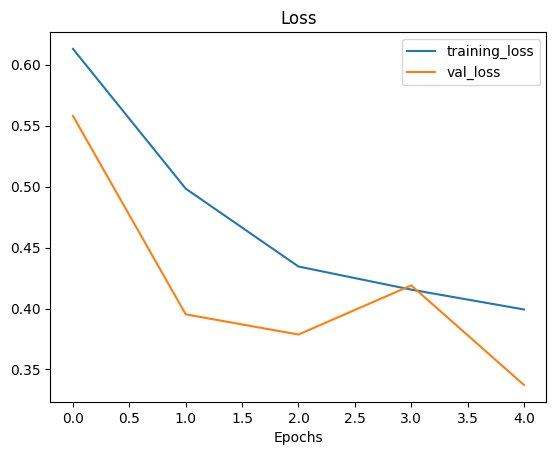

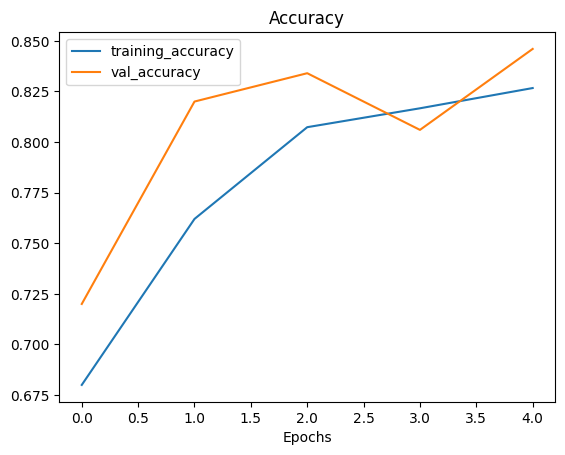

In [22]:
# Check out the model architecture
model_5.summary()
# Plot loss curves of model_5 results
plot_training_history(history_5)

## 6-  CNN model (using augmentation) Try to beat the overfitting


In [23]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "pizza_steak//train",
    image_size=(224, 224),
    batch_size=32,
    label_mode="binary",
    shuffle=True
)
valid_ds = tf.keras.utils.image_dataset_from_directory(
    "pizza_steak//test",
    image_size=(224, 224),
    batch_size=32,
    label_mode="binary",
    shuffle=True
)
# data Augmentation
from tensorflow.keras.layers import RandomShear

data_augmentation = tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal"),             # horizontal_flip=True
        tf.keras.layers.RandomRotation(20/360.0),             # rotation_range=20 degrees
        tf.keras.layers.RandomZoom(height_factor=0.2, width_factor=0.2),         # zoom_range=0.2
        tf.keras.layers.RandomTranslation(height_factor=0.2, width_factor=0.2),  # width/height_shift_range=0.2
        RandomShear(x_factor=0.2, y_factor=0.0),               # shear_range≈0.2 along x
    ])
model_6 = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(224, 224, 3)),
        tf.keras.layers.Rescaling(1./255),
        data_augmentation,
        tf.keras.layers.Conv2D(10,3,activation="relu"),
        tf.keras.layers.MaxPool2D(pool_size=2),
        tf.keras.layers.Conv2D(10,3,activation="relu"),
        tf.keras.layers.MaxPool2D(),
        tf.keras.layers.Conv2D(10,3,activation="relu"),
        tf.keras.layers.MaxPool2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(1, activation="sigmoid")
        ])

model_6.compile(loss="binary_crossentropy",
                optimizer="adam",
                metrics=["accuracy"])

history_6 = model_6.fit(train_ds,
                        epochs=5,
                        validation_data=valid_ds)

Found 1500 files belonging to 2 classes.
Found 500 files belonging to 2 classes.
Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.5960 - loss: 0.6614 - val_accuracy: 0.7620 - val_loss: 0.5185
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.7207 - loss: 0.5484 - val_accuracy: 0.8120 - val_loss: 0.4145
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.7493 - loss: 0.5233 - val_accuracy: 0.8480 - val_loss: 0.3808
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.7500 - loss: 0.4997 - val_accuracy: 0.8020 - val_loss: 0.4111
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.7607 - loss: 0.5059 - val_accuracy: 0.8300 - val_loss: 0.3982


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 109, 109, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 52, 52, 10)     │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 26, 26, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 6760)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │         6,761 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,585 (103.85 KB)

 Trainable params: 8,861 (34.61 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 17,724 (69.24 KB)

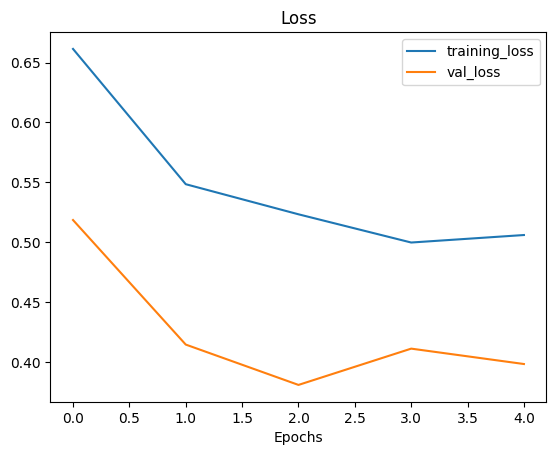

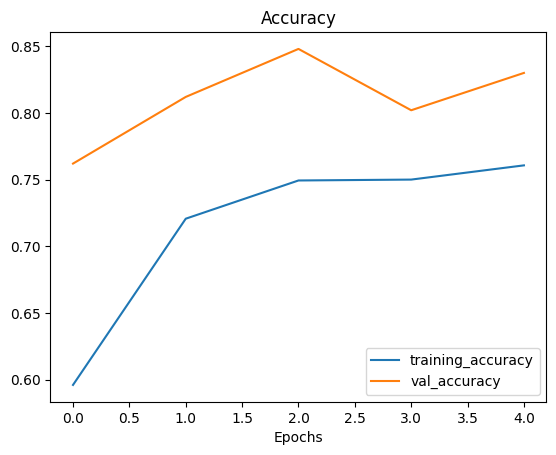

In [24]:
# Check out the model architecture
model_5.summary()
# Plot loss curves of model_5 results
plot_training_history(history_6)

## 7-  rerun model_1 (TinyVGG) with augmentation layer


In [25]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "pizza_steak//train",
    image_size=(224, 224),
    batch_size=32,
    label_mode="binary",
    shuffle=True,
    seed=42
)
valid_ds = tf.keras.utils.image_dataset_from_directory(
    "pizza_steak//test",
    image_size=(224, 224),
    batch_size=32,
    label_mode="binary",
    shuffle=True,
    seed=42
)
# data Augmentation
from tensorflow.keras.layers import RandomShear
data_augmentation = tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal"),             # horizontal_flip=True
        tf.keras.layers.RandomRotation(20/360.0),             # rotation_range=20 degrees
        tf.keras.layers.RandomZoom(height_factor=0.2, width_factor=0.2),         # zoom_range=0.2
        tf.keras.layers.RandomTranslation(height_factor=0.2, width_factor=0.2),  # width/height_shift_range=0.2
        RandomShear(x_factor=0.2, y_factor=0.0)               # shear_range≈0.2 along x
    ])

Found 1500 files belonging to 2 classes.
Found 500 files belonging to 2 classes.


In [26]:
# Create a CNN model (same as Tiny VGG but for binary classification - https://poloclub.github.io/cnn-explainer/ )
model_8 = Sequential([
  tf.keras.layers.Input(shape=(224, 224, 3)),
  tf.keras.layers.Rescaling(1./255),
  data_augmentation,  
  tf.keras.layers.Conv2D(10, 3, activation='relu', input_shape=(224, 224, 3)), # same input shape as our images
  tf.keras.layers.Conv2D(10, 3, activation='relu'),
  tf.keras.layers.MaxPool2D(),
  tf.keras.layers.Conv2D(10, 3, activation='relu'),
  tf.keras.layers.Conv2D(10, 3, activation='relu'),
  tf.keras.layers.MaxPool2D(),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile the model
model_8.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# Fit the model
history_8 = model_8.fit(train_ds,
                        epochs=5,
                        steps_per_epoch=len(train_ds),
                        validation_data=valid_ds,
                        validation_steps=len(valid_ds))

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - accuracy: 0.6067 - loss: 0.6484 - val_accuracy: 0.8180 - val_loss: 0.4421
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.7267 - loss: 0.5433 - val_accuracy: 0.6860 - val_loss: 0.5725
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - accuracy: 0.7480 - loss: 0.5190 - val_accuracy: 0.7380 - val_loss: 0.5148
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - accuracy: 0.7540 - loss: 0.5055 - val_accuracy: 0.8140 - val_loss: 0.3707
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.7600 - loss: 0.5081 - val_accuracy: 0.8520 - val_loss: 0.3631


In [27]:
# Check model_1 architecture (same as model_8)
model_1.summary()
# Check model_8 architecture (same as model_1)
model_8.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        28,091 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,305 (364.48 KB)

 Trainable params: 31,101 (121.49 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_7 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │        28,091 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,305 (364.48 KB)

 Trainable params: 31,101 (121.49 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,204 (242.99 KB)

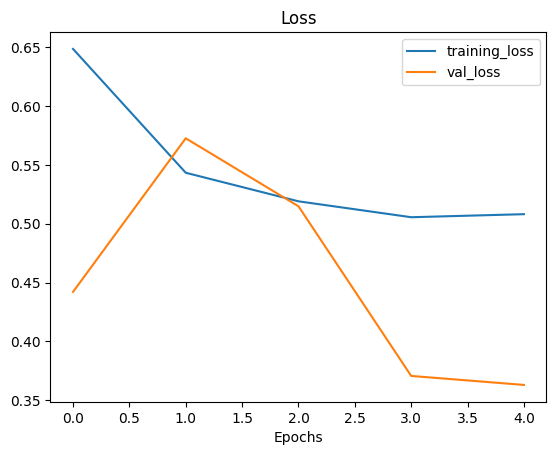

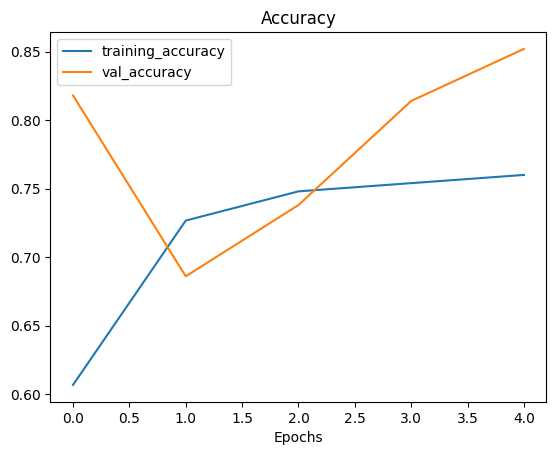

In [28]:
# Check out the TinyVGG model performance
plot_training_history(history_8)

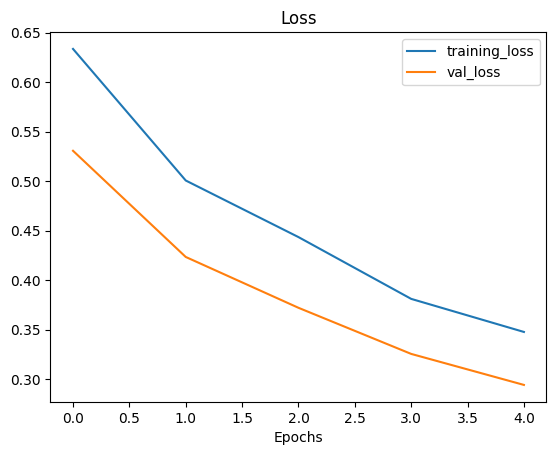

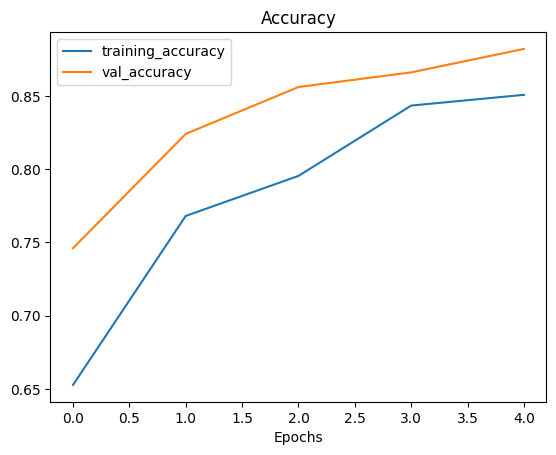

In [29]:
# How does this training curve look compared to the one above?
plot_training_history(history_1)

## Review and test

In [30]:
# Classes we're working with
print(class_names)

['pizza' 'steak']


--2026-04-22 12:29:45--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-steak.jpeg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1978213 (1.9M) [image/jpeg]
Saving to: ‘03-steak.jpeg.1’

03-steak.jpeg.1     100%[===================>]   1.89M  --.-KB/s    in 0.06s   

2026-04-22 12:29:45 (31.3 MB/s) - ‘03-steak.jpeg.1’ saved [1978213/1978213]



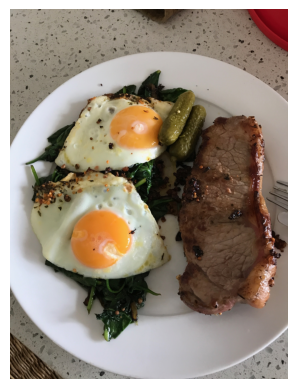

In [31]:
# View our example image
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-steak.jpeg 
steak = mpimg.imread("03-steak.jpeg")
plt.imshow(steak)
plt.axis(False);

In [32]:
steak.shape

(4032, 3024, 3)

In [38]:
from utils import load_and_prep_image

steak = load_and_prep_image("03-steak.jpeg", img_shape=224)

In [39]:
# Add an extra axis
print(f"Shape before new dimension: {steak.shape}")
steak = tf.expand_dims(steak, axis=0) # add an extra dimension at axis 0
#steak = steak[tf.newaxis, ...] # alternative to the above, '...' is short for 'every other dimension'
print(f"Shape after new dimension: {steak.shape}")
steak

Shape before new dimension: (224, 224, 3)
Shape after new dimension: (1, 224, 224, 3)


<tf.Tensor: shape=(1, 224, 224, 3), dtype=float32, numpy=
array([[[[0.6377451 , 0.6220588 , 0.57892156],
         [0.6504902 , 0.63186276, 0.5897059 ],
         [0.63186276, 0.60833335, 0.5612745 ],
         ...,
         [0.52156866, 0.05098039, 0.09019608],
         [0.49509802, 0.04215686, 0.07058824],
         [0.52843136, 0.07745098, 0.10490196]],

        [[0.6617647 , 0.6460784 , 0.6107843 ],
         [0.6387255 , 0.6230392 , 0.57598037],
         [0.65588236, 0.63235295, 0.5852941 ],
         ...,
         [0.5352941 , 0.06862745, 0.09215686],
         [0.529902  , 0.05931373, 0.09460784],
         [0.5142157 , 0.05539216, 0.08676471]],

        [[0.6519608 , 0.6362745 , 0.5892157 ],
         [0.6392157 , 0.6137255 , 0.56764704],
         [0.65637255, 0.6269608 , 0.5828431 ],
         ...,
         [0.53137255, 0.06470589, 0.08039216],
         [0.527451  , 0.06862745, 0.1       ],
         [0.52254903, 0.05196078, 0.0872549 ]],

        ...,

        [[0.49313724, 0.42745098, 

In [43]:
# Make a prediction on custom image tensor
pred = model_8.predict(steak)
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


array([[0.9435532]], dtype=float32)

In [44]:
# Remind ourselves of our class names
class_names
# We can index the predicted class by rounding the prediction probability
pred_class = class_names[int(tf.round(pred)[0][0])]
pred_class

np.str_('steak')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


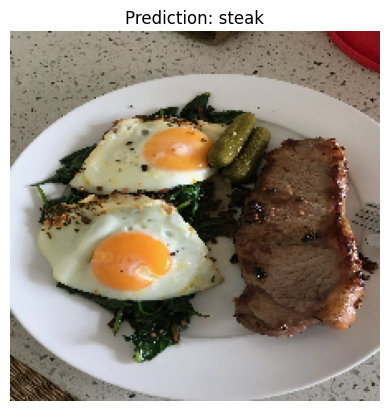

In [46]:
def pred_and_plot(model, filename, class_names):
  """
  Imports an image located at filename, makes a prediction on it with
  a trained model and plots the image with the predicted class as the title.
  """
  # Import the target image and preprocess it
  img = load_and_prep_image(filename)

  # Make a prediction
  pred = model.predict(tf.expand_dims(img, axis=0))

  # Get the predicted class
  pred_class = class_names[int(tf.round(pred)[0][0])]

  # Plot the image and predicted class
  plt.imshow(img)
  plt.title(f"Prediction: {pred_class}")
  plt.axis(False)
  
# Test our model on a custom image
pred_and_plot(model_8, "03-steak.jpeg", class_names)

--2026-04-22 12:36:01--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-pizza-dad.jpeg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2874848 (2.7M) [image/jpeg]
Saving to: ‘03-pizza-dad.jpeg.8’

03-pizza-dad.jpeg.8 100%[===================>]   2.74M  --.-KB/s    in 0.07s   

2026-04-22 12:36:02 (41.7 MB/s) - ‘03-pizza-dad.jpeg.8’ saved [2874848/2874848]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


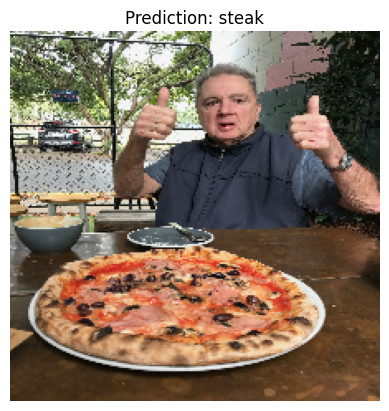

In [57]:
# Download another test image and make a prediction on it
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-pizza-dad.jpeg 
pred_and_plot(model_8, "03-pizza-dad.jpeg", class_names)

# Multiclass
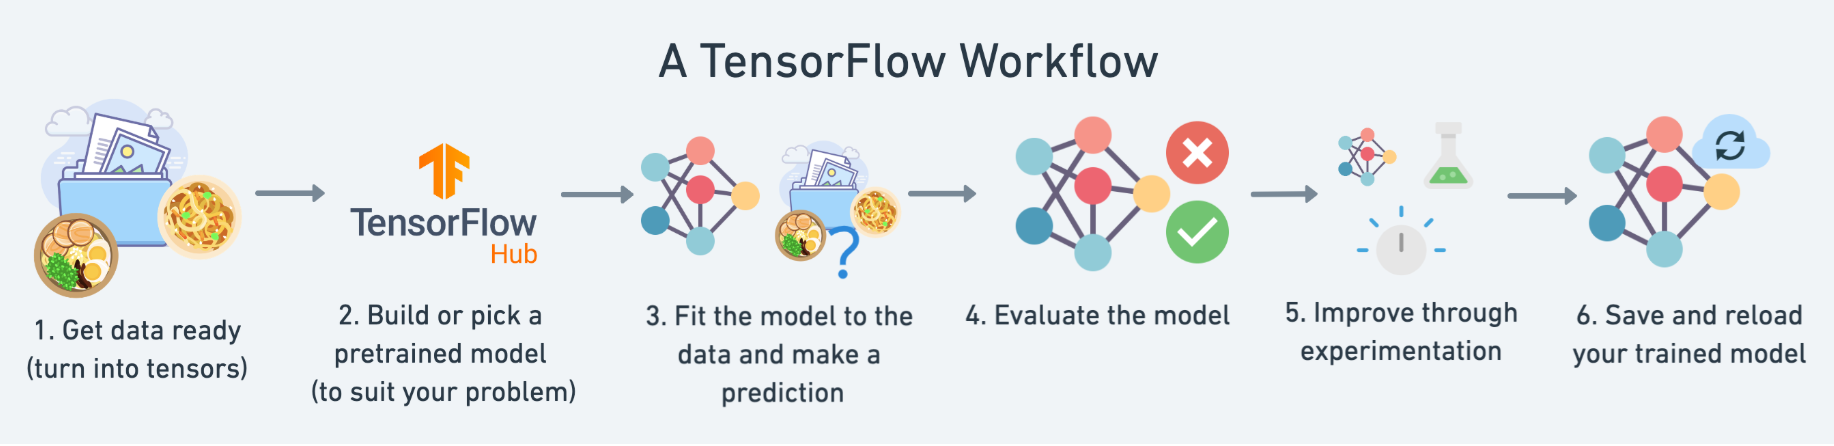

### 1. Import and become one with the data


In [58]:
# import zipfile

# # Download zip file of 10_food_classes images
# # See how this data was created - https://github.com/mrdbourke/tensorflow-deep-learning/blob/main/extras/image_data_modification.ipynb
# !wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip 

# # Unzip the downloaded file
# zip_ref = zipfile.ZipFile("10_food_classes_all_data.zip", "r")
# zip_ref.extractall()
# zip_ref.close()

--2026-04-22 12:38:36--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 192.178.170.207, 74.125.29.207, 172.217.208.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|192.178.170.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 519183241 (495M) [application/zip]
Saving to: ‘10_food_classes_all_data.zip’

10_food_classes_all 100%[===================>] 495.13M  39.8MB/s    in 14s     

2026-04-22 12:38:50 (35.0 MB/s) - ‘10_food_classes_all_data.zip’ saved [519183241/519183241]



In [59]:
import os

# Walk through 10_food_classes directory and list number of files
for dirpath, dirnames, filenames in os.walk("10_food_classes_all_data"):
  print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

There are 2 directories and 0 images in '10_food_classes_all_data'.
There are 10 directories and 0 images in '10_food_classes_all_data/test'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/ice_cream'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/chicken_curry'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/steak'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/sushi'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/chicken_wings'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/grilled_salmon'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/hamburger'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/pizza'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/ramen'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/fried_rice'.
There are 

In [61]:
train_dir = "10_food_classes_all_data/train/"
test_dir = "10_food_classes_all_data/test/"

# Get the class names for our multi-class dataset
import pathlib
import numpy as np

data_dir = pathlib.Path(train_dir)
class_names = np.array(sorted([item.name for item in data_dir.glob('*')]))
print(class_names)

['chicken_curry' 'chicken_wings' 'fried_rice' 'grilled_salmon' 'hamburger'
 'ice_cream' 'pizza' 'ramen' 'steak' 'sushi']


Image shape: (512, 408, 3)


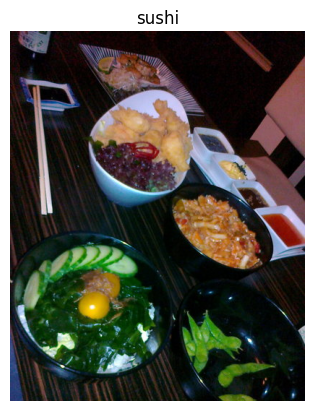

In [65]:
# View a random image from the training dataset
import random
img = view_random_image(target_dir=train_dir,
                        target_class=random.choice(class_names)) # get a random class name

### 2- Preprocess the data (prepare it for a model)

In [66]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "10_food_classes_all_data/train/",
    image_size=(224, 224),
    batch_size=32,
    label_mode="categorical",
    shuffle=True,
    seed=42
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    "10_food_classes_all_data/test/",
    image_size=(224, 224),
    batch_size=32,
    label_mode="categorical",
    shuffle=True,
    seed=42
)
# # data Augmentation
# from tensorflow.keras.layers import RandomShear
# data_augmentation = tf.keras.Sequential([
#         tf.keras.layers.RandomFlip("horizontal"),             # horizontal_flip=True
#         tf.keras.layers.RandomRotation(20/360.0),             # rotation_range=20 degrees
#         tf.keras.layers.RandomZoom(height_factor=0.2, width_factor=0.2),         # zoom_range=0.2
#         tf.keras.layers.RandomTranslation(height_factor=0.2, width_factor=0.2),  # width/height_shift_range=0.2
#         RandomShear(x_factor=0.2, y_factor=0.0)               # shear_range≈0.2 along x
#     ])

Found 7500 files belonging to 10 classes.
Found 2500 files belonging to 10 classes.


### 3. Create a model (start with a baseline) - TinyVGG

In [67]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Input, Rescaling

# Create our model (a clone of model_8, except to be multi-class)
model_9 = Sequential([
  Input(shape=(224, 224, 3)),
  Rescaling(1./255),
  Conv2D(10, 3, activation='relu'),
  Conv2D(10, 3, activation='relu'),
  MaxPool2D(),
  Conv2D(10, 3, activation='relu'),
  Conv2D(10, 3, activation='relu'),
  MaxPool2D(),
  Flatten(),
  Dense(10, activation='softmax') # changed to have 10 neurons (same as number of classes) and 'softmax' activation
])

# Compile the model
model_9.compile(loss="categorical_crossentropy", # changed to categorical_crossentropy
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

### 4. Fit a model 

In [68]:
# Fit the model
history_9 = model_9.fit(train_ds, # now 10 different classes 
                        epochs=5,
                        validation_data=test_ds)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - accuracy: 0.2219 - loss: 2.1425 - val_accuracy: 0.2868 - val_loss: 1.9905
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - accuracy: 0.3669 - loss: 1.8382 - val_accuracy: 0.3108 - val_loss: 1.9429
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - accuracy: 0.5732 - loss: 1.2822 - val_accuracy: 0.2868 - val_loss: 2.3473
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 14s 60ms/step - accuracy: 0.7945 - loss: 0.6360 - val_accuracy: 0.2628 - val_loss: 3.5371
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 14s 60ms/step - accuracy: 0.9344 - loss: 0.2117 - val_accuracy: 0.2428 - val_loss: 5.0535


### 5. Evaluate the model

In [69]:
# Evaluate on the test data
model_9.evaluate(test_ds)

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.2428 - loss: 5.0535


[5.0534868240356445, 0.24279999732971191]

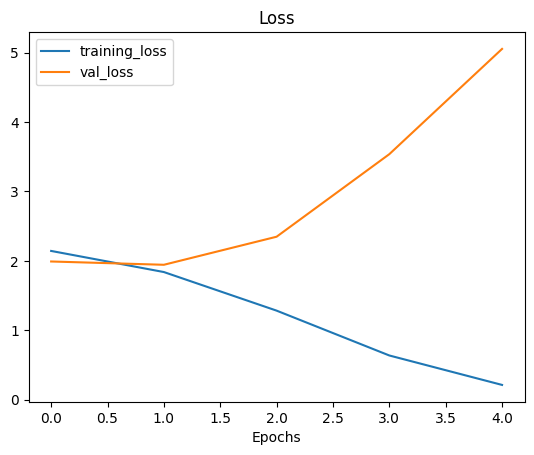

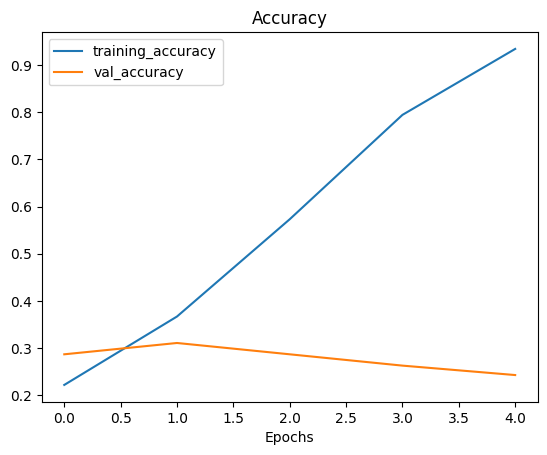

In [70]:
# Check out the model's loss curves on the 10 classes of data (note: this function comes from above in the notebook)
plot_training_history(history_9)

In [71]:
# Try a simplified model (removed two layers)
model_10 = Sequential([
  Input(shape=(224, 224, 3)),
  Rescaling(1./255),
  Conv2D(10, 3, activation='relu'),
  MaxPool2D(),
  Conv2D(10, 3, activation='relu'),
  MaxPool2D(),
  Flatten(),
  Dense(10, activation='softmax')
])

model_10.compile(loss='categorical_crossentropy',
                 optimizer=tf.keras.optimizers.Adam(),
                 metrics=['accuracy'])

history_10 = model_10.fit(train_ds,
                          epochs=5,
                          validation_data=test_ds)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.2475 - loss: 2.0979 - val_accuracy: 0.3192 - val_loss: 1.9660
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.4329 - loss: 1.6862 - val_accuracy: 0.3604 - val_loss: 1.8487
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.6021 - loss: 1.2232 - val_accuracy: 0.3124 - val_loss: 2.0725
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.7793 - loss: 0.7175 - val_accuracy: 0.2992 - val_loss: 2.5641
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.9109 - loss: 0.3374 - val_accuracy: 0.2908 - val_loss: 3.0632


In [98]:
# use data augemntation 

# data Augmentation

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(20/360.0),
    tf.keras.layers.RandomZoom(height_factor=0.2, width_factor=0.2),
    tf.keras.layers.RandomTranslation(height_factor=0.2, width_factor=0.2)
])

# Create our model (a clone of model_8, except to be multi-class)
model_11 = Sequential([
  Input(shape=(224, 224, 3)),
  Rescaling(1./255),
  data_augmentation,
  Conv2D(10, 3, activation='relu'),
  Conv2D(10, 3, activation='relu'),
  MaxPool2D(),
  Conv2D(10, 3, activation='relu'),
  Conv2D(10, 3, activation='relu'),
  MaxPool2D(),
  Flatten(),
  Dense(10, activation='softmax') # changed to have 10 neurons (same as number of classes) and 'softmax' activation
])


# Compile the cloned model (same setup as used for model_10)
model_11.compile(loss="categorical_crossentropy",
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

# Fit the model
history_11 = model_11.fit(train_ds, # use augmented data
                          epochs=5,
                          validation_data=test_ds)

Epoch 1/5


235/235 ━━━━━━━━━━━━━━━━━━━━ 20s 80ms/step - accuracy: 0.1489 - loss: 2.2854 - val_accuracy: 0.2496 - val_loss: 2.0741
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 19s 80ms/step - accuracy: 0.2467 - loss: 2.0996 - val_accuracy: 0.3076 - val_loss: 1.9742
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 19s 81ms/step - accuracy: 0.2809 - loss: 2.0377 - val_accuracy: 0.3532 - val_loss: 1.8847
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 19s 80ms/step - accuracy: 0.2980 - loss: 1.9964 - val_accuracy: 0.3784 - val_loss: 1.8241
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 19s 80ms/step - accuracy: 0.3041 - loss: 1.9720 - val_accuracy: 0.3788 - val_loss: 1.8108


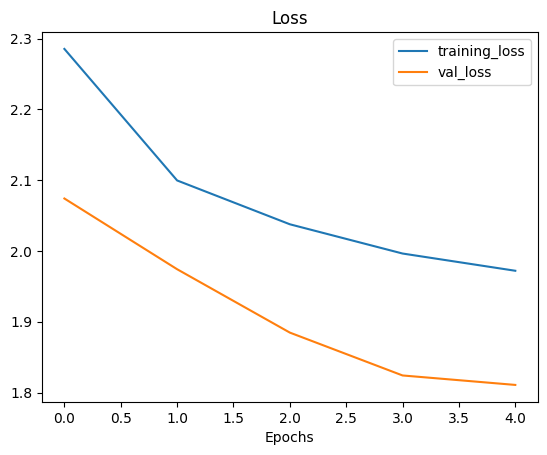

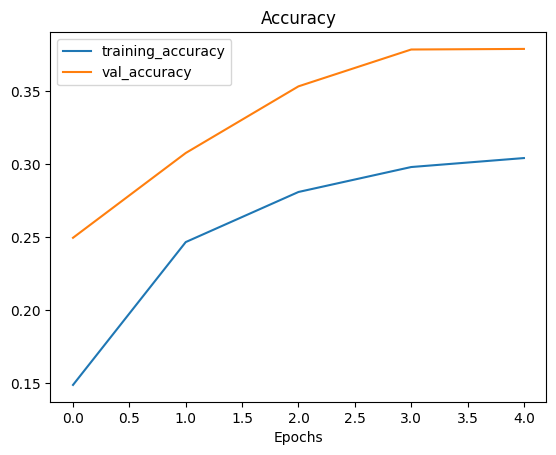

In [99]:
# Check out the loss curves of model_10
plot_training_history(history_11)

In [100]:
# What classes has our model been trained on?
class_names

array(['chicken_curry', 'chicken_wings', 'fried_rice', 'grilled_salmon',
       'hamburger', 'ice_cream', 'pizza', 'ramen', 'steak', 'sushi'],
      dtype='<U14')

In [ ]:
# -q is for "quiet"
# !wget -q https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-pizza-dad.jpeg
# !wget -q https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-steak.jpeg
# !wget -q https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-hamburger.jpeg
# !wget -q https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-sushi.jpeg

In [106]:
# Check the output of the predict function
pred = model_11.predict(tf.expand_dims(img, axis=0))
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


array([[0.05251449, 0.08365075, 0.02443595, 0.08645027, 0.06317193,
        0.27286896, 0.01618235, 0.12031709, 0.06164896, 0.21875925]],
      dtype=float32)

In [108]:
# Adjust function to work with multi-class
def pred_and_plot(model, filename, class_names):
  """
  Imports an image located at filename, makes a prediction on it with
  a trained model and plots the image with the predicted class as the title.
  """
  # Import the target image and preprocess it
  img = load_and_prep_image(filename)

  # Make a prediction
  pred = model.predict(tf.expand_dims(img, axis=0))

  # Get the predicted class
  if len(pred[0]) > 1: # check for multi-class
    pred_class = class_names[pred.argmax()] # if more than one output, take the max
  else:
    pred_class = class_names[int(tf.round(pred)[0][0])] # if only one output, round

  # Plot the image and predicted class
  plt.imshow(img)
  plt.title(f"Prediction: {pred_class}")
  plt.axis(False);

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


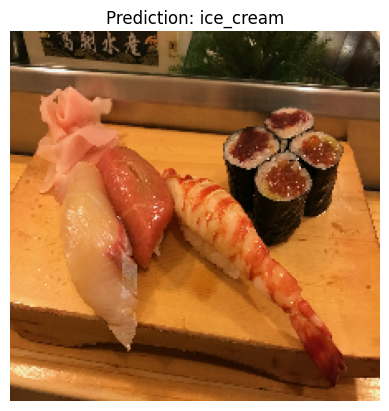

In [111]:
# Find the predicted class name
pred_and_plot(model_11, "03-sushi.jpeg", class_names)

In [112]:
model_11.save("saved_trained_model.keras")
loaded_model_11 = tf.keras.models.load_model("saved_trained_model.keras")
loaded_model_11.evaluate(test_ds)

79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.3788 - loss: 1.8108


[1.810780644416809, 0.37880000472068787]